In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
# This will prompt you to upload the kaggle.json file
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
# Define a path on your Google Drive to store the data
%cd /content/drive/MyDrive/
!mkdir -p car_body_data
%cd car_body_data/
# Download the dataset
!kaggle datasets download -d mayurmahurkar/stanford-car-body-type-data
# Unzip it
!unzip -q stanford-car-body-type-data.zip

/content/drive/MyDrive
/content/drive/MyDrive/car_body_data
Dataset URL: https://www.kaggle.com/datasets/mayurmahurkar/stanford-car-body-type-data
License(s): other
100% 936M/936M [00:11<00:00, 81.8MB/s]



In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# Adjust if your path is different
ROOT = Path("/content/drive/MyDrive/car_body_data")

if not ROOT.exists():
    # Try to locate it
    print("Not at expected path. Searching...")
    for p in Path("/content/drive/MyDrive").rglob("stanford*"):
        print(p)
else:
    print(f"Root: {ROOT}")
    print("Top-level contents:")
    for item in sorted(ROOT.iterdir()):
        print(f"  {'[DIR] ' if item.is_dir() else '[FILE]'} {item.name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Root: /content/drive/MyDrive/car_body_data
Top-level contents:
  [FILE] best_model.pth
  [FILE] data_info.txt
  [DIR]  split
  [FILE] stanford-car-body-type-data.zip
  [DIR]  stanford_cars_type
  [FILE] stanford_cars_type.csv


In [4]:
from pathlib import Path
import os

DATASET = Path("/content/drive/MyDrive/car_body_data/stanford_cars_type")

print("Contents of stanford_cars_type/:")
for item in sorted(DATASET.iterdir()):
    if item.is_dir():
        n_files = len(list(item.iterdir()))
        print(f"  [DIR]  {item.name}  ({n_files} items)")
    else:
        print(f"  [FILE] {item.name}")

# Also peek at the CSV
import pandas as pd
csv_path = Path("/content/drive/MyDrive/car_body_data/stanford_cars_type.csv")
df = pd.read_csv(csv_path)
print("\nCSV shape:", df.shape)
print("CSV columns:", list(df.columns))
print("\nFirst 3 rows:")
print(df.head(3))
print("\nClass distribution (if there's a label column):")
print(df.iloc[:, -1].value_counts() if df.shape[1] > 1 else "only 1 column")

print(Path("/content/drive/MyDrive/car_body_data/data_info.txt").read_text())


Contents of stanford_cars_type/:
  [DIR]  Cab  (719 items)
  [DIR]  Convertible  (1036 items)
  [DIR]  Coupe  (1088 items)
  [DIR]  Hatchback  (554 items)
  [DIR]  Minivan  (250 items)
  [DIR]  Other  (609 items)
  [DIR]  SUV  (1437 items)
  [DIR]  Sedan  (1907 items)
  [DIR]  Van  (253 items)
  [DIR]  Wagon  (291 items)

CSV shape: (8144, 7)
CSV columns: ['Unnamed: 0', 'file_name', 'car_code', 'car_name', 'brand', 'car_type', 'new_filename']

First 3 rows:
   Unnamed: 0  file_name  car_code                    car_name  brand  \
0           0  00001.jpg        14         Audi TTS Coupe 2012   Audi   
1           1  00002.jpg         3         Acura TL Sedan 2012  Acura   
2           2  00003.jpg        91  Dodge Dakota Club Cab 2007  Dodge   

  car_type                          new_filename  
0    Coupe         00001_Audi TTS Coupe 2012.jpg  
1    Sedan         00002_Acura TL Sedan 2012.jpg  
2      Cab  00003_Dodge Dakota Club Cab 2007.jpg  

Class distribution (if there's a label c

In [ ]:
import os
import shutil
import random
from pathlib import Path

random.seed(42)

SOURCE = Path("/content/drive/MyDrive/car_body_data/stanford_cars_type")
DEST = Path("/content/drive/MyDrive/car_body_data/split")

SPLITS = {"train": 0.70, "valid": 0.15, "test": 0.15}
MERGE_OTHER_INTO_CAB = True  # set False to keep "Other" as its own class

# --- Step 1: Prepare destination ---
if DEST.exists():
    shutil.rmtree(DEST)
DEST.mkdir(parents=True)

# --- Step 2: Discover class folders ---
classes = sorted([d.name for d in SOURCE.iterdir() if d.is_dir()])
print(f"Found {len(classes)} classes: {classes}\n")

# --- Step 3: Collect files per class (optionally merging Other -> Cab) ---
class_files = {}
for cls in classes:
    files = [f for f in (SOURCE / cls).iterdir()
             if f.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    target_cls = "Cab" if (MERGE_OTHER_INTO_CAB and cls == "Other") else cls

    if target_cls not in class_files:
        class_files[target_cls] = []
    class_files[target_cls].extend(files)

print(f"After merge: {len(class_files)} classes\n")

# --- Step 4: Split each class ---
for cls, files in sorted(class_files.items()):
    random.shuffle(files)
    n = len(files)
    n_train = int(n * SPLITS["train"])
    n_val = int(n * SPLITS["valid"])

    buckets = {
        "train": files[:n_train],
        "valid": files[n_train:n_train + n_val],
        "test":  files[n_train + n_val:],
    }

    for split, flist in buckets.items():
        out_dir = DEST / split / cls
        out_dir.mkdir(parents=True, exist_ok=True)
        for f in flist:
            shutil.copy2(f, out_dir / f.name)

    print(f"{cls:<15} total={n:5d} | "
          f"train={len(buckets['train']):5d} | "
          f"val={len(buckets['valid']):4d} | "
          f"test={len(buckets['test']):4d}")

print(f"\n✅ Split complete: {DEST}")

# Verify
for split in ["train", "valid", "test"]:
    split_dir = DEST / split
    total = sum(len(list((split_dir / c).iterdir())) for c in split_dir.iterdir())
    print(f"  {split:<6}: {total} images, {len(list(split_dir.iterdir()))} classes")

Found 10 classes: ['Cab', 'Convertible', 'Coupe', 'Hatchback', 'Minivan', 'Other', 'SUV', 'Sedan', 'Van', 'Wagon']

After merge: 9 classes

Cab             total= 1328 | train=  929 | val= 199 | test= 200
Convertible     total= 1036 | train=  725 | val= 155 | test= 156
Coupe           total= 1088 | train=  761 | val= 163 | test= 164
Hatchback       total=  554 | train=  387 | val=  83 | test=  84
Minivan         total=  250 | train=  175 | val=  37 | test=  38
SUV             total= 1437 | train= 1005 | val= 215 | test= 217
Sedan           total= 1907 | train= 1334 | val= 286 | test= 287
Van             total=  253 | train=  177 | val=  37 | test=  39
Wagon           total=  291 | train=  203 | val=  43 | test=  45

✅ Split complete: /content/drive/MyDrive/car_body_data/split
  train : 5696 images, 9 classes
  valid : 1218 images, 9 classes
  test  : 1230 images, 9 classes


In [ ]:
!pip install -q torch torchvision pillow matplotlib tqdm

In [ ]:
# Example: Data augmentation and loading
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets and dataloaders
train_dir = '/content/drive/MyDrive/car_body_data/split/train' # Adjust path if necessary
val_dir = '/content/drive/MyDrive/car_body_data/split/valid'
test_dir = '/content/drive/MyDrive/car_body_data/split/test'

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Model setup
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(num_ftrs, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# ... training loop ...

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

EPOCHS = 25
best_val_acc = 0.0
best_path = "/content/drive/MyDrive/car_body_data/best_model.pth"
classes = train_dataset.classes

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    losses, preds, labels = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            if train:
                optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            if train:
                loss.backward()
                optimizer.step()
            losses.append(loss.item() * imgs.size(0))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    n = len(labels)
    return sum(losses)/n, accuracy_score(labels, preds), f1_score(labels, preds, average="macro")

print(f"Classes ({len(classes)}): {classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}\n")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, _ = run_epoch(train_loader, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    marker = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), best_path)
        marker = "  best"

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val loss={vl_loss:.4f} acc={vl_acc:.4f} f1={vl_f1:.4f} | "
          f"{time.time()-t0:.0f}s{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

# ---------- Test ----------
model.load_state_dict(torch.load(best_path))
te_loss, te_acc, te_f1 = run_epoch(test_loader, train=False)

print(f"\n{'='*60}")
print(f"FINAL TEST RESULTS")
print(f"{'='*60}")
print(f"  Loss:      {te_loss:.4f}")
print(f"  Accuracy:  {te_acc:.4f}")
print(f"  F1-macro:  {te_f1:.4f}")

# Per-class report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(lbls.numpy())

print(f"\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/car_body_data/confusion_matrix.png", dpi=120)
plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history["train_loss"], label="train")
ax1.plot(history["val_loss"], label="val")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="train")
ax2.plot(history["val_acc"], label="val")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/car_body_data/training_curves.png", dpi=120)
plt.show()

Classes (9): ['Cab', 'Convertible', 'Coupe', 'Hatchback', 'Minivan', 'SUV', 'Sedan', 'Van', 'Wagon']
Train: 5696 | Val: 1218 | Test: 1230

Epoch 01/25 | train loss=1.6657 acc=0.3864 | val loss=1.2070 acc=0.5805 f1=0.4049 | 98s  best
Epoch 02/25 | train loss=1.2459 acc=0.5562 | val loss=0.9500 acc=0.6617 f1=0.5830 | 98s  best
Epoch 03/25 | train loss=1.0375 acc=0.6250 | val loss=0.9309 acc=0.6757 f1=0.6091 | 98s  best
Epoch 04/25 | train loss=0.9223 acc=0.6743 | val loss=0.7016 acc=0.7570 f1=0.7193 | 96s  best
Epoch 05/25 | train loss=0.7997 acc=0.7170 | val loss=0.6176 acc=0.7750 f1=0.7306 | 100s  best
Epoch 06/25 | train loss=0.7350 acc=0.7421 | val loss=0.5608 acc=0.8087 f1=0.7915 | 100s  best
Epoch 07/25 | train loss=0.6620 acc=0.7637 | val loss=0.6374 acc=0.7759 f1=0.7667 | 98s
Epoch 08/25 | train loss=0.6220 acc=0.7858 | val loss=0.5255 acc=0.8259 f1=0.8186 | 91s  best
Epoch 09/25 | train loss=0.5552 acc=0.8009 | val loss=0.5035 acc=0.8284 f1=0.8095 | 94s  best
Epoch 10/25 | train

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score
import time

ROOT = "/content/drive/MyDrive/car_body_data/split"
BEST_PATH = "/content/drive/MyDrive/car_body_data/best_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(f"{ROOT}/train", transform=train_tf)
val_ds   = datasets.ImageFolder(f"{ROOT}/valid", transform=eval_tf)
classes = train_ds.classes

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Load saved model
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model = model.to(DEVICE)

print(f"Loaded: {BEST_PATH}")
print(f"Classes ({len(classes)}): {classes}")

# Fresh optimizer for the final stretch
optimizer = optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=7)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    losses, preds, labels = [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            if train:
                optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            if train:
                loss.backward()
                optimizer.step()
            losses.append(loss.item() * imgs.size(0))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    n = len(labels)
    return sum(losses)/n, accuracy_score(labels, preds), f1_score(labels, preds, average="macro")

# Baseline check
vl_loss, vl_acc, vl_f1 = run_epoch(val_loader, train=False)
print(f"Current val: loss={vl_loss:.4f} acc={vl_acc:.4f} f1={vl_f1:.4f}\n")

best_val_acc = vl_acc

for epoch in range(19, 26):
    t0 = time.time()
    tr_loss, tr_acc, _ = run_epoch(train_loader, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader, train=False)
    scheduler.step()

    marker = ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), BEST_PATH)
        marker = "  best"

    print(f"Epoch {epoch:02d}/25 | "
          f"train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val loss={vl_loss:.4f} acc={vl_acc:.4f} f1={vl_f1:.4f} | "
          f"{time.time()-t0:.0f}s{marker}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Loaded: /content/drive/MyDrive/car_body_data/best_model.pth
Classes (9): ['Cab', 'Convertible', 'Coupe', 'Hatchback', 'Minivan', 'SUV', 'Sedan', 'Van', 'Wagon']
Current val: loss=0.4043 acc=0.8851 f1=0.8814



KeyboardInterrupt: 

In [6]:
import torch, time
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. GPU check
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    !nvidia-smi
else:
    print("⚠️  NO GPU — running on CPU. That's why it's slow.")

# 2. DataLoader speed test
ROOT = "/content/drive/MyDrive/car_body_data/split"
eval_tf = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
ds = datasets.ImageFolder(f"{ROOT}/train", transform=eval_tf)
loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)

t0 = time.time()
for i, (imgs, lbls) in enumerate(loader):
    if i == 10:  # 10 batches
        break
elapsed = time.time() - t0
print(f"\n10 batches loaded in {elapsed:.1f}s → {elapsed/10*178:.0f}s per epoch just for loading")

CUDA available: True
Device: Tesla T4
Tue Sep 15 23:36:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   66C    P0             29W /   70W |    3309MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------

FINAL TEST RESULTS
  Accuracy:  0.8659
  F1-macro:  0.8689

              precision    recall  f1-score   support

         Cab     0.9461    0.7900    0.8610       200
 Convertible     0.8671    0.8782    0.8726       156
       Coupe     0.7651    0.7744    0.7697       164
   Hatchback     0.7500    0.6786    0.7125        84
     Minivan     0.9487    0.9737    0.9610        38
         SUV     0.9533    0.9401    0.9466       217
       Sedan     0.8272    0.9338    0.8773       287
         Van     0.9512    1.0000    0.9750        39
       Wagon     0.8444    0.8444    0.8444        45

    accuracy                         0.8659      1230
   macro avg     0.8726    0.8681    0.8689      1230
weighted avg     0.8686    0.8659    0.8652      1230



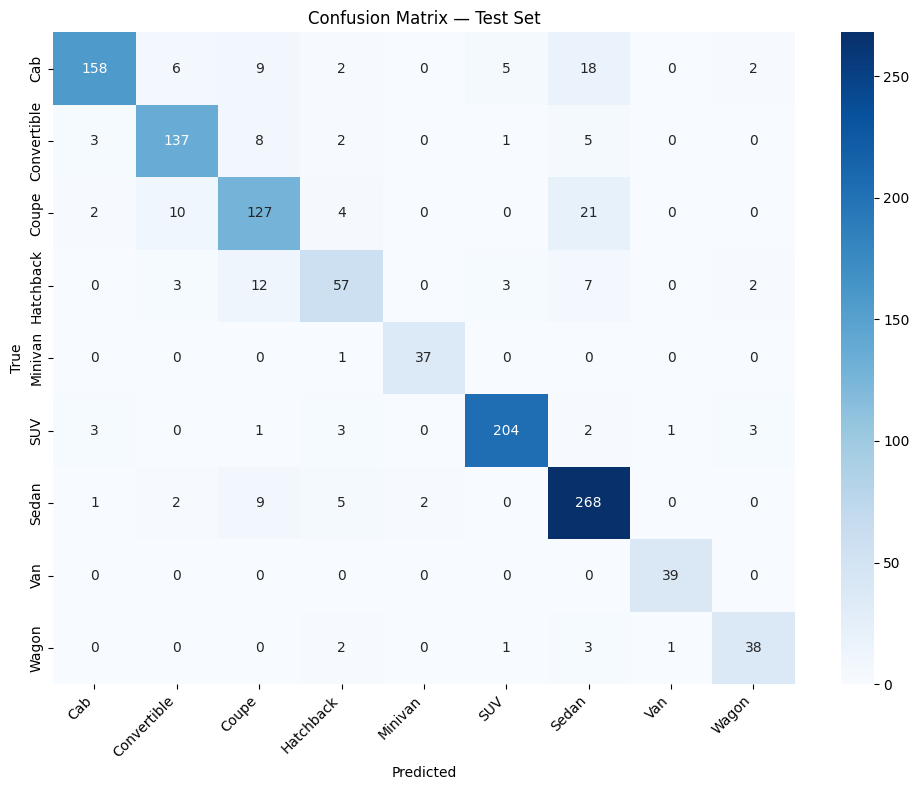


Saved model_info.json for deployment


In [7]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = "/content/drive/MyDrive/car_body_data/split"
BEST_PATH = "/content/drive/MyDrive/car_body_data/best_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_ds = datasets.ImageFolder(f"{ROOT}/test", transform=eval_tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)
classes = test_ds.classes

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
model = model.to(DEVICE).eval()

criterion = nn.CrossEntropyLoss()
losses, preds, labels = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        out = model(imgs)
        losses.append(criterion(out, lbls).item() * imgs.size(0))
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(lbls.cpu().numpy())

print(f"{'='*60}")
print(f"FINAL TEST RESULTS")
print(f"{'='*60}")
print(f"  Accuracy:  {accuracy_score(labels, preds):.4f}")
print(f"  F1-macro:  {f1_score(labels, preds, average='macro'):.4f}")
print(f"\n{classification_report(labels, preds, target_names=classes, digits=4)}")

cm = confusion_matrix(labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/car_body_data/confusion_matrix.png", dpi=120)
plt.show()

# Save the model info needed for deployment
import json
with open("/content/drive/MyDrive/car_body_data/model_info.json", "w") as f:
    json.dump({
        "classes": classes,
        "backbone": "resnet50",
        "num_classes": len(classes),
        "input_size": 224,
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
    }, f, indent=2)
print("\nSaved model_info.json for deployment")

In [12]:
from google.colab import files

files.download("/content/drive/MyDrive/car_body_data/best_model.pth")
files.download("/content/drive/MyDrive/car_body_data/model_info.json")
files.download("/content/drive/MyDrive/car_body_data/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>